### Implementing simple Chatbot Using LangGraph


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")
LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING", "true")
HF_TOKEN = os.getenv("HF_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen-qwq-32b")
llm_groq.invoke("Hey I am Yash and i like to play cricket")

AIMessage(content="\n<think>\nOkay, the user is introducing himself as Yash and mentions he likes to play cricket. I want to respond in a friendly and engaging way.\n\nFirst, I should acknowledge his name and his interest in cricket. Maybe ask him to tell me more about his experience with the sport. That way, he can share more details if he wants to.\n\nI should keep the tone casual and positive. Maybe mention some common aspects of cricket that he might enjoy talking about, like favorite players, positions, or teams. It's good to leave it open-ended so he can choose what to discuss.\n\nI should avoid making assumptions beyond what he's shared. Just a simple, welcoming response to encourage further conversation. Let me make sure there are no typos and it flows naturally.\n</think>\n\nHey Yash! That's awesome! Cricket is such a fun sport. Do you prefer batting or bowling? And are there any players or teams you really look up to? 😊", additional_kwargs={}, response_metadata={'token_usage'

In [5]:
def superbot(state: State):
    return {"messages": [llm_groq.invoke(state["messages"])]}

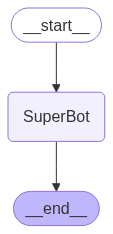

In [6]:
from IPython.display import Image, display

graph = StateGraph(State)

graph.add_node("SuperBot", superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [7]:
graph_builder.invoke({"messages": "Hi,My name is Yash And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Yash And I like cricket', additional_kwargs={}, response_metadata={}, id='17a7e56b-37bd-448e-89a9-10e417976769'),
  AIMessage(content="\n<think>\nOkay, the user introduced themselves as Yash and mentioned they like cricket. I should respond in a friendly way. Let me start by greeting them back and acknowledging their name and interest.\n\nI need to make sure to mention cricket specifically. Maybe ask a follow-up question about their favorite team or player to keep the conversation going. Also, since they might be a sports fan, I can relate by mentioning the World Cup or a recent event in cricket. Let me check the current year to see if there's a recent tournament. Since the last World Cup was in 2023, I can reference that.\n\nWait, the user might be from India given the name Yash. Maybe they support the Indian team. I should phrase it in a way that invites them to share more. Also, keep the tone positive and enthusiastic. Let me put it 

#### Streaming the responses


In [8]:
for event in graph_builder.stream({"messages": "Hello My name is Yash"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='\n<think>\nOkay, the user said, "Hello My name is Yash." I need to respond appropriately. Let me start by greeting them back. I should mention their name to make it personal. Maybe say something like, "Hello Yash! How can I assist you today?" That\'s friendly and opens the conversation. Wait, should I add anything else? Maybe ask how they\'re doing as well? Let me check the example response. The assistant used, "Hello Yash! How can I assist you today?" That\'s good. Keep it simple and offer help. I think that\'s sufficient. Don\'t overcomplicate it. Just make sure it\'s polite and invites them to state their needs.\n</think>\n\nHello Yash! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 16, 'total_tokens': 171, 'completion_time': 0.376456836, 'prompt_time': 0.00310146, 'queue_time': 0.243249624, 'total_time': 0.379558296}, 'model_name': 'qwen-qwq-32b', 'system

In [9]:
for event in graph_builder.stream(
    {"messages": "Hello My name is Yash"}, stream_mode="values"
):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Yash', additional_kwargs={}, response_metadata={}, id='aa54dbce-966a-4b13-8bed-0f31413a6390')]}
{'messages': [HumanMessage(content='Hello My name is Yash', additional_kwargs={}, response_metadata={}, id='aa54dbce-966a-4b13-8bed-0f31413a6390'), AIMessage(content='\n<think>\nOkay, the user said "Hello My name is Yash". I need to respond appropriately. Let me think.\n\nFirst, I should greet them back. "Hello Yash!" That\'s friendly. Then maybe ask how I can assist them today. Keep it open-ended so they can state their needs. Make sure it\'s polite and welcoming. Let me check if there\'s anything else I should consider. Maybe mention that I\'m here to help with any questions or tasks. Yeah, that should work. Alright, time to put it all together.\n</think>\n\nHello Yash! Nice to meet you. How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything specific! 😊', additional_kwargs={}, response